# False alarm rate simulation

Empirical false alarm rate of `GridDetector` with `MeanCUSUM` under the null
(i.i.d. standard normal). The threshold is calibrated to a target false alarm
probability over a stream of length $T$, and we verify that the realized false
alarm rate stays controlled as the stream grows.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from gridcp import GridDetector
from gridcp.calibration import (
    calibrate_threshold_false_alarm,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import MeanCUSUM

## Simulation parameters

In the paper example, K_CAL and K_SIM are both set to 1.000.000. NB: This takes a long time to run.

In [ ]:
ALPHA = 0.05      # Target false alarm probability
N_CAL = 100       # Calibration stream length (T)
K_CAL = 1_000_000 # Number of paths to simulate for calibration
K_SIM = 1_000_000 # Number of null paths to simulate for estimating the false alarm rate
L_MAX = 10_000    # Maximum stream length to simulate for estimating the false alarm rate

score = MeanCUSUM()
detector = GridDetector(score=score)
sampler = lambda rng=None: rng.standard_normal()

## Calibrate threshold

In [3]:
start_time = time.perf_counter()
threshold = calibrate_threshold_false_alarm(
    score,
    false_alarm_probability=ALPHA,
    n_paths=K_CAL,
    stream_len=N_CAL,
    pre_sampler=sampler,
    rng=0,
)
print(
    f"Calibration done in {time.perf_counter() - start_time:.2f}s. "
    f"Threshold: {threshold[0]:.4f}"
)

Calibration done in 1.72s. Threshold: 3.0189


## Simulate alarm times under the null

In [ ]:
detector_cal = with_calibrated_threshold(detector, threshold)
alarm_times = mc_alarm_times(detector_cal, K_SIM, L_MAX, pre_sampler=sampler, rng=1)
print(f"Done. {K_SIM:,} null paths, threshold={threshold[0]:.4f}")

# Store values in a .npz file for later analysis and plotting
#np.savez("simulation_results/fa_sim_results.npz", alarm_times=alarm_times, threshold=threshold, alpha=np.float64(ALPHA), n_cal=np.int64(N_CAL), k_sim=np.int64(K_SIM), l_max=np.int64(L_MAX),)
#print("Saved results to simulation_results/fa_sim_results.npz")

Done. 10,000 null paths, threshold=3.0189


## False alarm rate over the stream length

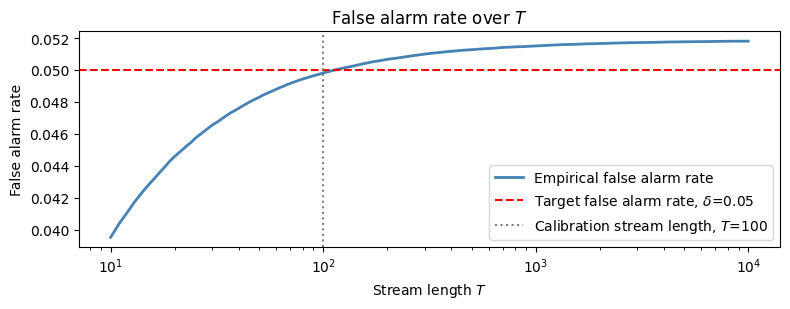

In [11]:
# If data stored in .npz file, load it here for plotting
data = np.load("simulation_results/fa_sim_results.npz")
alarm_times = data["alarm_times"]
threshold = data["threshold"]
ALPHA = float(data["alpha"])
N_CAL = int(data["n_cal"])
K_SIM = int(data["k_sim"])
L_MAX = int(data["l_max"])

L_SWEEP = np.unique(np.geomspace(N_CAL // 10, L_MAX, 5_000).astype(int))
at_sorted = np.sort(alarm_times)
far_curve = np.searchsorted(at_sorted, L_SWEEP, side="left") / K_SIM

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(
    L_SWEEP[:-1],
    far_curve[:-1],
    color="steelblue",
    linewidth=2,
    label="Empirical false alarm rate",
)
ax.axhline(
    ALPHA,
    color="r",
    linestyle="--",
    label=rf"Target false alarm rate, $\delta$={ALPHA}",
)
ax.axvline(
    N_CAL,
    color="gray",
    linestyle=":",
    label=f"Calibration stream length, $T$={N_CAL}",
)
ax.set_xscale("log")
ax.set_xlabel("Stream length $T$")
ax.set_ylabel("False alarm rate")
ax.set_title("False alarm rate over $T$")
ax.legend()
plt.tight_layout()
#plt.savefig("fa_rate.pdf", bbox_inches="tight")
plt.show()